<a href="https://colab.research.google.com/github/gitmystuff/DSChunks/blob/main/GLM_v_OLS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparison Between OLS and GLM

OLS Model Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     2175.
Date:                Sat, 26 Oct 2024   Prob (F-statistic):           4.38e-88
Time:                        20:56:05   Log-Likelihood:                -371.56
No. Observations:                 100   AIC:                             751.1
Df Residuals:                      96   BIC:                             761.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2493      1.039 

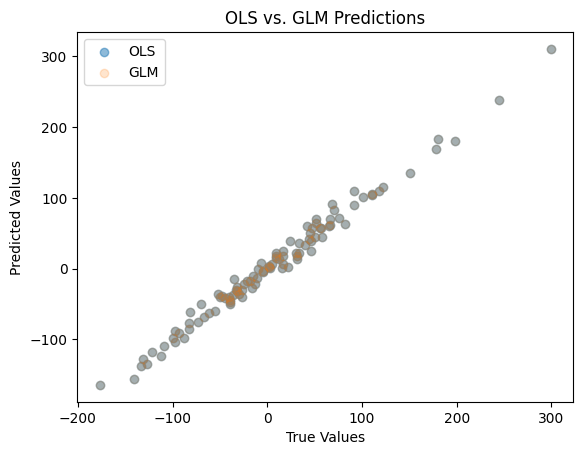

In [ ]:
import numpy as np
import statsmodels.api as sm
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

# Generate data with 3 features and 1 target
X, y = make_regression(n_samples=100, n_features=3, noise=10, random_state=42)

# Add a constant term to the predictor matrix for the intercept
X = sm.add_constant(X)

# Fit OLS model
ols_model = sm.OLS(y, X).fit()

# Fit GLM model (with Gaussian family and identity link, equivalent to OLS)
glm_model = sm.GLM(y, X, family=sm.families.Gaussian()).fit()

# Print model summaries
print("OLS Model Summary:")
print(ols_model.summary())
print("\nGLM Model Summary:")
print(glm_model.summary())

# Compare some key statistics
print("\nComparison:")
print(f"OLS R-squared: {ols_model.rsquared:.4f}")
# Use pseudo-R-squared for GLM (e.g., McFadden's R-squared)
print(f"GLM Pseudo-R-squared (McFadden): {1 - glm_model.llf / glm_model.llnull:.4f}")
print(f"OLS AIC: {ols_model.aic:.4f}")
print(f"GLM AIC: {glm_model.aic:.4f}")

# You can also access other statistics like BIC, log-likelihood, etc.

# Visualize predictions (optional)
y_pred_ols = ols_model.predict(X)
y_pred_glm = glm_model.predict(X)

plt.scatter(y, y_pred_ols, label="OLS", alpha=0.5)
plt.scatter(y, y_pred_glm, label="GLM", alpha=0.2)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("OLS vs. GLM Predictions")
plt.legend()
plt.show()

It's important to remember that **R-squared is not a suitable measure of goodness-of-fit for GLMs in general**, and especially not for those with non-linear link functions like the log link.

R-squared is based on the concept of variance explained, which doesn't directly translate to GLMs with non-identity link functions.

Instead of R-squared, you should use other metrics to assess the goodness-of-fit for your GLM, such as:

* **AIC (Akaike Information Criterion):**  A measure of relative model quality that penalizes models with more parameters. Lower AIC values indicate a better fit.
* **BIC (Bayesian Information Criterion):** Similar to AIC, but with a stronger penalty for model complexity.
* **Deviance:** A measure of the difference between the fitted model and the saturated model (a model that perfectly fits the data). Lower deviance indicates a better fit.
* **Log-likelihood:** The logarithm of the likelihood function, which measures how well the model explains the observed data. Higher log-likelihood indicates a better fit.



